<a href="https://colab.research.google.com/github/rayynaldgitau/Group-4-AI-work/blob/master/Group_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
shared_folder = "/content/drive/MyDrive/"
output_file = f"{shared_folder}features.csv"

uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
df = pd.read_csv(uci_url)

df.columns = [c.strip() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

missing_total = df.isna().sum().sum()
print(f"Total missing values: {missing_total}")
assert missing_total == 0, "Warning: Missing values detected!"
print(f"Correct dataset loaded successfully! Shape: {df.shape[0]:,} rows, {df.shape[1]} columns.")

Mounted at /content/drive
Total missing values: 0
Correct dataset loaded successfully! Shape: 19,735 rows, 29 columns.


In [ ]:

df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn"
}
df["season"] = df["date"].dt.month.map(season_map)

df = pd.concat([df, pd.get_dummies(df["season"], prefix="season", dtype=int)], axis=1)

print("--- Rubric Sanity Check: Correlation with Appliances ---")
print(df[["rv1", "rv2", "Appliances"]].corr()["Appliances"][["rv1", "rv2"]])

df_clean = df.drop(columns=["rv1", "rv2", "season"])
df_clean.to_csv(output_file, index=False)

print(f"\nSuccess! Cleaned dataset saved to: {output_file}")
print(f"Final shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns.")

--- Rubric Sanity Check: Correlation with Appliances ---
rv1   -0.011145
rv2   -0.011145
Name: Appliances, dtype: float64

Success! Cleaned dataset saved to: /content/drive/MyDrive/features.csv
Final shape: 19,735 rows, 32 columns.


In [ ]:
preview_cols = ["date", "Appliances", "hour", "day_of_week", "is_weekend", "season_spring", "season_winter"]
display(df_clean[preview_cols].head())
display(df_clean.describe())

,date,Appliances,hour,day_of_week,is_weekend,season_spring,season_winter
0,2016-01-11 17:00:00,60,17,0,0,0,1
1,2016-01-11 17:10:00,60,17,0,0,0,1
2,2016-01-11 17:20:00,50,17,0,0,0,1
3,2016-01-11 17:30:00,50,17,0,0,0,1
4,2016-01-11 17:40:00,60,17,0,0,0,1


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day_of_week,is_weekend,season_spring,season_winter
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:30:00,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,755.522602,79.750418,4.039752,38.330834,3.760707,11.502002,2.977249,0.277274,0.640334,0.359666
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,729.300000,24.000000,0.000000,1.000000,-6.600000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,750.933333,70.333333,2.000000,29.000000,0.900000,6.000000,1.000000,0.000000,0.000000,0.000000
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,756.100000,83.666667,3.666667,40.000000,3.433333,12.000000,3.000000,0.000000,1.000000,0.000000
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,760.933333,91.666667,5.500000,40.000000,6.566667,17.000000,5.000000,1.000000,1.000000,1.000000
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,772.300000,100.000000,14.000000,66.000000,15.500000,23.000000,6.000000,1.000000,1.000000,1.000000
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,7.399441,14.901088,2.451221,11.794719,4.194648,6.921953,1.985617,0.447664,0.479914,0.479914


In [ ]:

print("--- FIRST 5 ROWS (PREVIEW) ---")

preview_cols = ["date", "hour", "day_of_week", "is_weekend",
                "season_spring", "season_winter"]
display(df_clean[preview_cols].head())


print(f"\nTotal Rows: {df_clean.shape[0]:,}")
print(f"Total Columns: {df_clean.shape[1]}")


print("\n--- DATA TYPES ---")
print(df_clean.dtypes)


--- FIRST 5 ROWS (PREVIEW) ---


,date,hour,day_of_week,is_weekend,season_spring,season_winter
0,2016-01-11 17:00:00,17,0,0,0,1
1,2016-01-11 17:10:00,17,0,0,0,1
2,2016-01-11 17:20:00,17,0,0,0,1
3,2016-01-11 17:30:00,17,0,0,0,1
4,2016-01-11 17:40:00,17,0,0,0,1



Total Rows: 19,735
Total Columns: 32

--- DATA TYPES ---
date             datetime64[ns]
Appliances                int64
lights                    int64
T1                      float64
RH_1                    float64
T2                      float64
RH_2                    float64
T3                      float64
RH_3                    float64
T4                      float64
RH_4                    float64
T5                      float64
RH_5                    float64
T6                      float64
RH_6                    float64
T7                      float64
RH_7                    float64
T8                      float64
RH_8                    float64
T9                      float64
RH_9                    float64
T_out                   float64
Press_mm_hg             float64
RH_out                  float64
Windspeed               float64
Visibility              float64
Tdewpoint               float64
hour                      int32
day_of_week               int32
is_weekend    

In [ ]:
summary_stats = df_clean.describe()
display(summary_stats)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day_of_week,is_weekend,season_spring,season_winter
count,19735,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,2016-03-20 05:30:00,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,...,755.522602,79.750418,4.039752,38.330834,3.760707,11.502002,2.977249,0.277274,0.640334,0.359666
min,2016-01-11 17:00:00,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,...,729.300000,24.000000,0.000000,1.000000,-6.600000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-02-14 23:15:00,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,...,750.933333,70.333333,2.000000,29.000000,0.900000,6.000000,1.000000,0.000000,0.000000,0.000000
50%,2016-03-20 05:30:00,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,...,756.100000,83.666667,3.666667,40.000000,3.433333,12.000000,3.000000,0.000000,1.000000,0.000000
75%,2016-04-23 11:45:00,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,...,760.933333,91.666667,5.500000,40.000000,6.566667,17.000000,5.000000,1.000000,1.000000,1.000000
max,2016-05-27 18:00:00,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,...,772.300000,100.000000,14.000000,66.000000,15.500000,23.000000,6.000000,1.000000,1.000000,1.000000
std,NaN,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,...,7.399441,14.901088,2.451221,11.794719,4.194648,6.921953,1.985617,0.447664,0.479914,0.479914


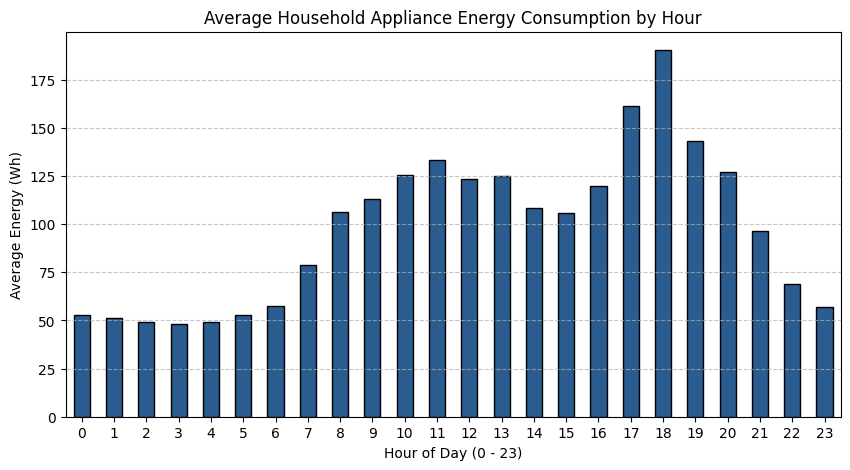

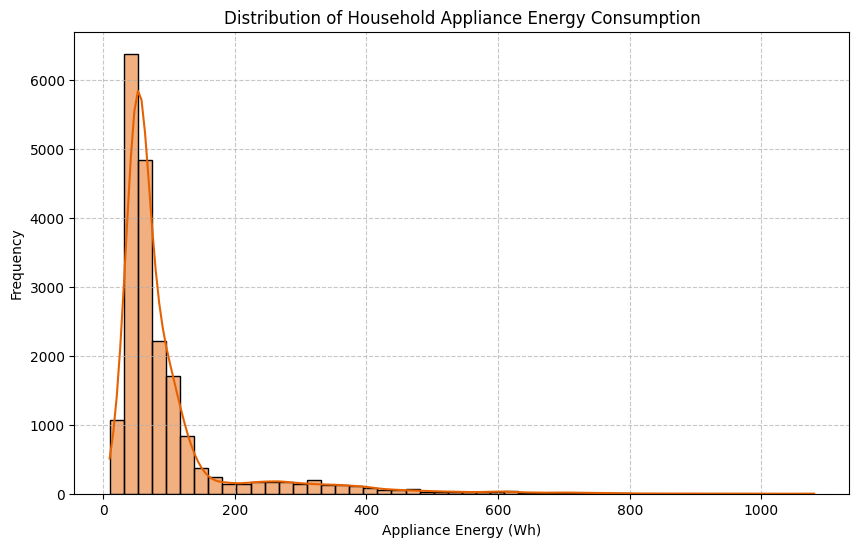

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


hourly_avg = df_clean.groupby("hour")["Appliances"].mean()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="bar", color="#2b5c8f", edgecolor="black")
plt.title("Average Household Appliance Energy Consumption by Hour")
plt.xlabel("Hour of Day (0 - 23)")
plt.ylabel("Average Energy (Wh)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig(f"{shared_folder}hourly_avg.png", dpi=150)
plt.show()

# 2. Target Distribution Histogram (Shows the right-skew for the Model Lead)
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Appliances'], bins=50, kde=True, color="#e66101")
plt.title("Distribution of Household Appliance Energy Consumption")
plt.xlabel("Appliance Energy (Wh)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

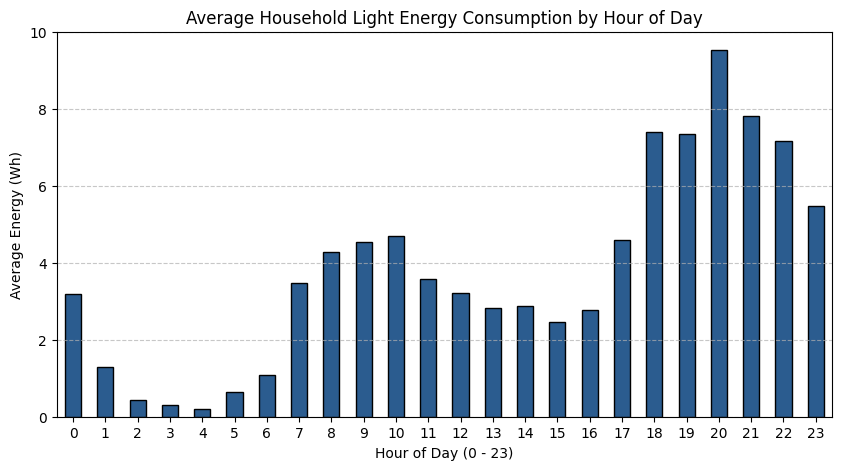

In [ ]:
import matplotlib.pyplot as plt

# Calculate hourly average for household lighting (in Wh)
hourly_lights_avg = df_clean.groupby("hour")["lights"].mean()

plt.figure(figsize=(10, 5))
hourly_lights_avg.plot(kind="bar", color="#2b5c8f", edgecolor="black")
plt.title("Average Household Light Energy Consumption by Hour of Day")
plt.xlabel("Hour of Day (0 - 23)")
plt.ylabel("Average Energy (Wh)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig(f"{shared_folder}hourly_lights_avg.png", dpi=150)
plt.show()

In [ ]:
print(df_clean.columns)

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'is_weekend',
       'season_spring', 'season_winter'],
      dtype='object')


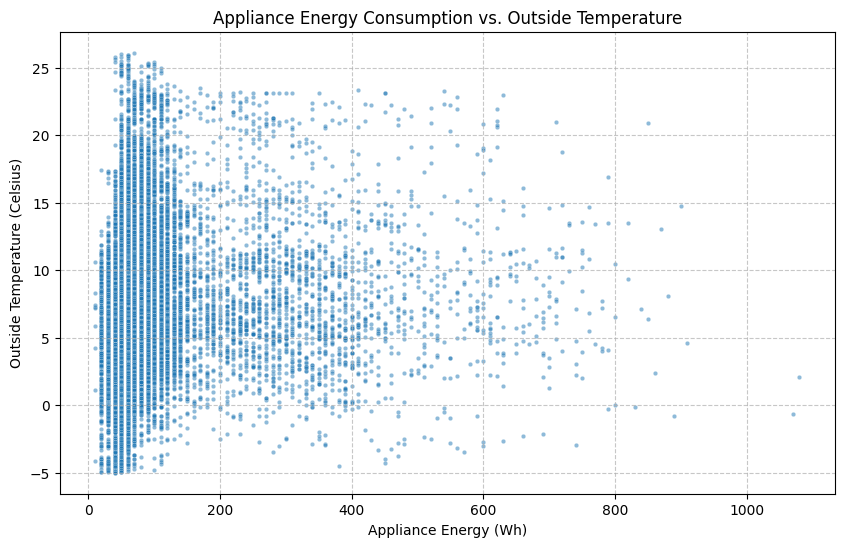

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x='Appliances', y='T_out', data=df_clean, alpha=0.5, s=10)
plt.title('Appliance Energy Consumption vs. Outside Temperature')
plt.xlabel('Appliance Energy (Wh)')
plt.ylabel('Outside Temperature (Celsius)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{shared_folder}appliance_vs_temp.png", dpi=150)
plt.show()

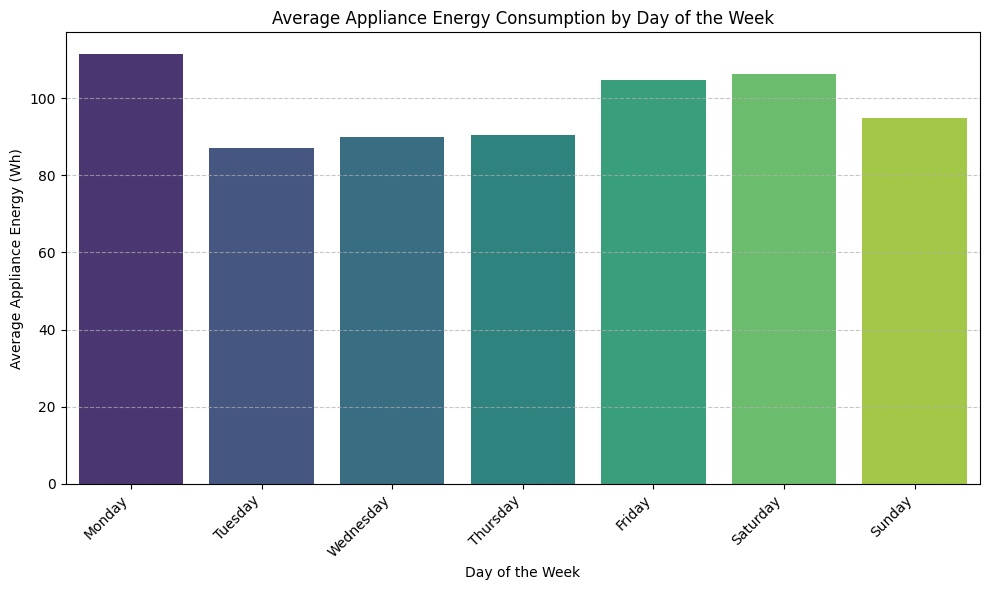

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average 'Appliances' consumption for each day of the week
daily_avg_appliances = df_clean.groupby('day_of_week')['Appliances'].mean().reset_index()

# Map day numbers to day names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg_appliances['day_name'] = daily_avg_appliances['day_of_week'].map(lambda x: day_names[x])

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='Appliances', hue='day_name', data=daily_avg_appliances, palette='viridis', legend=False)
plt.title('Average Appliance Energy Consumption by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Appliance Energy (Wh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{shared_folder}daily_avg_appliances.png", dpi=150)
plt.show()

In [ ]:
import numpy as np

# Separate features (X) and target (y)
target_col = "Appliances"
drop_cols = [target_col, "date"]

# Drop helper/target columns present in df_clean
drop_cols = [c for c in drop_cols if c in df_clean.columns]

X = df_clean.drop(columns=drop_cols)
y = df_clean[target_col]
feature_cols = list(X.columns)
print(f"\nFeature count: {len(feature_cols)}")
print(feature_cols)


# Time-series aware chronological split (80% Train, 20% Test)
split_idx = int(len(df_clean) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("--- Train/Test Split Completed ---")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")


Feature count: 30
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'is_weekend', 'season_spring', 'season_winter']
--- Train/Test Split Completed ---
Training features shape: (15788, 30)
Testing features shape:  (3947, 30)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Build and train Linear Regression pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Evaluate baseline
lr_preds = lr_pipeline.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("--- Model 1: Linear Regression Baseline ---")
print(f"Test RMSE: {lr_rmse:.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, lr_preds):.4f}")

--- Model 1: Linear Regression Baseline ---
Test RMSE: 86.4067
Test MAE:  52.0152


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Instant direct fit using optimized hyperparameters
rf_fast = RandomForestRegressor(
    n_estimators=100,         # 100 trees for fast estimation
    max_depth=10,             # Prevents deep, slow tree growth
    min_samples_leaf=20,      # Simplifies leaf nodes (faster computation)
    max_features=0.5,         # Uses 50% of features per split
    max_samples=0.2,          # Trains each tree on 20% of data (huge speedup)
    random_state=42,
    n_jobs=-1                 # Parallelizes across available CPU cores
)

# Train single model directly (no CV grid overhead)
rf_fast.fit(X_train, y_train)

# Evaluate Random Forest
rf_preds = rf_fast.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("\n--- Model 2: Tuned Random Forest ---")
print(f"Test RMSE: {rf_rmse:.4f}")
print(f"Test MAE:  {rf_mae:.4f}")
print(f"Test R2:   {rf_r2:.4f}")


--- Model 2: Tuned Random Forest ---
Test RMSE: 110.0240
Test MAE:  84.4471
Test R2:   -0.4606


In [ ]:
# Calculate Linear Regression metrics (if not already stored)
lr_preds = lr_pipeline.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("==========================================================")
print("              --- FULL MODEL COMPARISON ---              ")
print("==========================================================")
print(f"Linear Regression:  RMSE={lr_rmse:8.2f} | MAE={lr_mae:8.2f} | R2={lr_r2:7.4f}")
print(f"Random Forest:       RMSE={rf_rmse:8.2f} | MAE={rf_mae:8.2f} | R2={rf_r2:7.4f}")
print("==========================================================")

--- Full Model Comparison ---
Linear Regression:  RMSE=86.41  MAE=52.02  R2=0.0992
Random Forest:       RMSE=129.72  MAE=101.95  R2=-1.0304


In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dictionary of 5 additional fast baseline models
additional_models = {
    "Ridge Regression": Pipeline([('scaler', StandardScaler()), ('regressor', Ridge())]),
    "Lasso Regression": Pipeline([('scaler', StandardScaler()), ('regressor', Lasso(alpha=0.1, random_state=42))]),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42),
    "K-Nearest Neighbors": Pipeline([('scaler', StandardScaler()), ('regressor', KNeighborsRegressor(n_neighbors=15, n_jobs=-1))]),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, max_depth=10, max_samples=0.2, bootstrap=True, random_state=42, n_jobs=-1)
}

# Evaluate all 5 models fast
extra_results = {}
print("--- Training & Evaluating Additional 5 Models ---")
for name, model in additional_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    extra_results[name] = {"model": model, "preds": preds, "rmse": rmse, "mae": mae, "r2": r2}
    print(f"{name:20s}: RMSE={rmse:8.2f} | MAE={mae:8.2f} | R2={r2:7.4f}")

 Selected Best Model: Linear Regression
 Final Test RMSE: 86.4067
 Final Test MAE:  52.0152
 Final Test R2:   0.0992

Saved best model file to: /content/drive/MyDrive/trained_model.joblib
Saved evaluation predictions to: /content/drive/MyDrive/test_predictions.csv


In [ ]:
# Aggregate all models into a single dictionary
all_models_eval = {
    "Linear Regression": {"model": lr_pipeline, "preds": lr_preds, "rmse": lr_rmse, "mae": lr_mae, "r2": lr_r2},
    "Random Forest Regressor": {"model": rf_fast, "preds": rf_preds, "rmse": rf_rmse, "mae": rf_mae, "r2": rf_r2}
}

# Add the 5 extra models if they exist in memory
if 'extra_results' in locals():
    all_models_eval.update(extra_results)

# Find model with lowest RMSE overall
best_model_name = min(all_models_eval, key=lambda k: all_models_eval[k]["rmse"])
best_model = all_models_eval[best_model_name]["model"]
best_preds = all_models_eval[best_model_name]["preds"]

print("==================================================")
print(f" Selected Best Model: {best_model_name}")
print(f" Final Test RMSE: {all_models_eval[best_model_name]['rmse']:.4f}")
print(f" Final Test MAE:  {all_models_eval[best_model_name]['mae']:.4f}")
print(f" Final Test R2:   {all_models_eval[best_model_name]['r2']:.4f}")
print("==================================================")

In [ ]:
import os
import joblib

# Save artifacts to Drive
model_path = os.path.join(shared_folder, "trained_model.joblib")
test_data_path = os.path.join(shared_folder, "test_predictions.csv")

# Export model binaries
joblib.dump(best_model, model_path)
joblib.dump(lr_pipeline, os.path.join(shared_folder, "lr_model.pkl"))
joblib.dump(rf_fast, os.path.join(shared_folder, "rf_model.pkl"))
joblib.dump(feature_cols, os.path.join(shared_folder, "feature_cols.pkl"))
joblib.dump(X.median().to_dict(), os.path.join(shared_folder, "feature_defaults.pkl"))

# Export predictions dataset for Role 3 (Evaluation Lead)
eval_df = X_test.copy()
eval_df["Actual_Appliances"] = y_test
eval_df["Predicted_Appliances"] = best_preds
eval_df.to_csv(test_data_path, index=False)

print(f"\nSaved best model file to: {model_path}")
print(f"Saved evaluation predictions to: {test_data_path}")